In [1]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy


sys.path.append('..')
import plot_settings
plot_settings.apply()
colors = plot_settings.colors()

# Importing data

In [2]:
DT = 2
Q0 = 17921.57581 
#(data['I'][data['trajectory'] == 10].values)[0]  * 3600 / (data['C'][data['trajectory'] == 10].values)[0]  
#print(f'Q0: {Q0:.5f} As')

In [3]:

def read_data(file_name):
    df = pd.read_csv(
        f"Multi_data_bin/{file_name}.txt",
        delim_whitespace=True,
        comment="%",
        header=None
    )

    df.columns = ['u_par','C','t','E_cell (V)','I_cell (A)','Rx_cell (N)','u_cell (m)','E_ocv_cell (V)']

    # Sort by time within each batch
    return df



path = f'test_data_50beta_20p'

data = read_data(path)

#rename columns
data.columns = ['u_par','C','t','V_t','I','Rx','u','ocv']

data['u'] = data['u'] * -1e6
data['Rx'] = data['Rx'] * -1e-6
data['I'] = data['I'] * -1.
data['eta'] = data['V_t'] - data['ocv']


/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_69974/4124929483.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [4]:
# Add numeric trajectory id for each unique (C, u_par) pair
data['trajectory_id'] = data.groupby(['C', 'u_par'], sort=True).ngroup()

# Optional lookup table (one row per trajectory)
trajectory_lookup = (
    data[['C', 'u_par', 'trajectory_id']]
    .drop_duplicates()
    .sort_values('trajectory_id')
    .reset_index(drop=True)
)

print(trajectory_lookup)
print(f"Number of trajectories: {trajectory_lookup['trajectory_id'].nunique()}")

      C  u_par  trajectory_id
0   0.7   13.2              0
1   0.8    2.2              1
2   1.1   27.0              2
3   1.3   20.1              3
4   1.4   10.0              4
5   1.8   25.8              5
6   2.0   15.5              6
7   2.3   11.2              7
8   2.3   24.2              8
9   2.6   14.6              9
10  2.8    0.6             10
11  3.2   17.7             11
12  3.3    4.7             12
13  3.6    6.7             13
14  3.7   19.2             14
15  3.9   21.4             15
16  4.2   23.5             16
17  4.3   29.7             17
18  4.7    3.3             18
19  4.9    7.8             19
Number of trajectories: 20


In [5]:
# Add a trajectory column (reuse existing IDs if already available)
if 'trajectory_id' in data.columns:
	data['trajectory'] = data['trajectory_id']
else:
	data['trajectory'] = data.groupby(['C'], sort=True).ngroup()

display(data)

,u_par,C,t,V_t,I,Rx,u,ocv,eta,trajectory_id,trajectory
0,0.6,2.8,0,4.219347,13.939003,45.848423,-0.862395,4.324995,-0.105648,10,10
1,0.6,2.8,2,4.165714,13.939003,44.650311,-0.862395,4.320263,-0.154549,10,10
2,0.6,2.8,4,4.147898,13.939003,43.451001,-0.862395,4.315527,-0.167629,10,10
3,0.6,2.8,6,4.133791,13.939003,42.251690,-0.862395,4.310790,-0.176999,10,10
4,0.6,2.8,8,4.122085,13.939003,41.052379,-0.862395,4.306053,-0.183968,10,10
...,...,...,...,...,...,...,...,...,...,...,...
15401,20.1,1.3,2604,2.541534,6.471680,810.949943,-28.890233,3.265666,-0.724133,3,3
15402,20.1,1.3,2606,2.498076,6.471680,810.393120,-28.890233,3.263280,-0.765205,3,3
15403,20.1,1.3,2608,2.450700,6.471680,809.836297,-28.890233,3.260895,-0.810195,3,3
15404,20.1,1.3,2610,2.399577,6.471680,809.279474,-28.890233,3.258509,-0.858932,3,3


In [6]:
# Add finite-difference columns with the same length as `data`
dV = np.diff(data['V_t'].to_numpy()) / DT
dRx = np.diff(data['Rx'].to_numpy()) / DT

if len(dV) > 0:
    dV = np.append(dV, dV[-1])
    dRx = np.append(dRx, dRx[-1])
else:
    dV = np.array([0.0])
    dRx = np.array([0.0])

data['dV_t'] = dV
data['dRx'] = dRx

data[['V_t', 'Rx', 'dV_t', 'dRx']].head()

,V_t,Rx,dV_t,dRx
0,4.219347,45.848423,-0.026816,-0.599056
1,4.165714,44.650311,-0.008908,-0.599655
2,4.147898,43.451001,-0.007053,-0.599655
3,4.133791,42.251690,-0.005853,-0.599655
4,4.122085,41.052379,-0.005039,-0.599655


# Plotting data

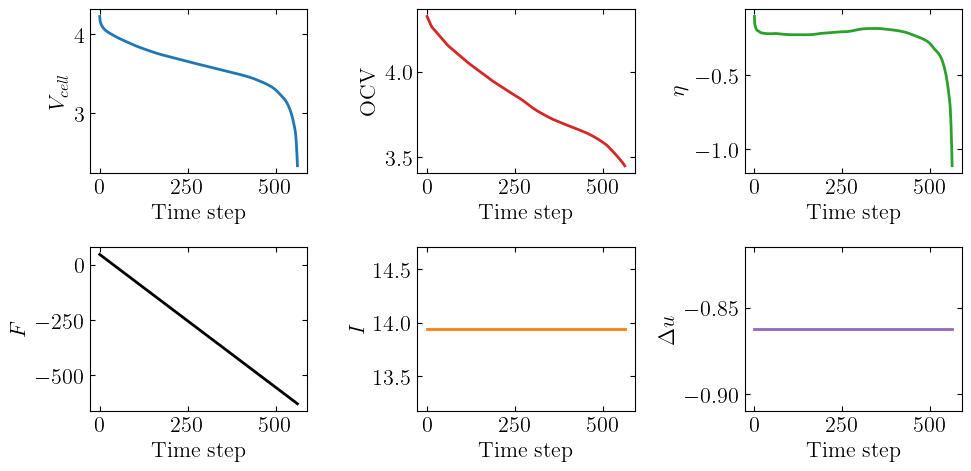

In [7]:

plot_idx = data['trajectory'] == 10
f, ax = plt.subplots(2, 3, figsize=(10, 5))
ax[0,0].plot(data['V_t'][plot_idx], '-', color = colors[0], lw = 2)
ax[0,0].set_xlabel('Time step')
ax[0,0].set_ylabel('$V_{cell}$')
ax[0,1].plot(data['ocv'][plot_idx], '-', color = colors[1], lw = 2)
ax[0,1].set_xlabel('Time step')
ax[0,1].set_ylabel('OCV')
ax[0,2].plot(data['eta'][plot_idx], '-', color = colors[2], lw = 2)
ax[0,2].set_xlabel('Time step')
ax[0,2].set_ylabel(r'$\eta$')
ax[1,0].plot(data['Rx'][plot_idx], lw = 2,color = colors[3])
ax[1,0].set_xlabel('Time step')
ax[1,0].set_ylabel(r'$F$')
ax[1,1].plot(data['I'][plot_idx], lw = 2,color = colors[4])
ax[1,1].set_xlabel('Time step')
ax[1,1].set_ylabel(r'$I$')
ax[1,2].plot(data['u'][plot_idx], lw = 2,color = colors[5])
ax[1,2].set_xlabel('Time step')
ax[1,2].set_ylabel(r'$\Delta u$')
#ax[].plot(data['ocv'][plot_idx], lw = 2,color = colors[4])

plt.tight_layout()
plt.show()

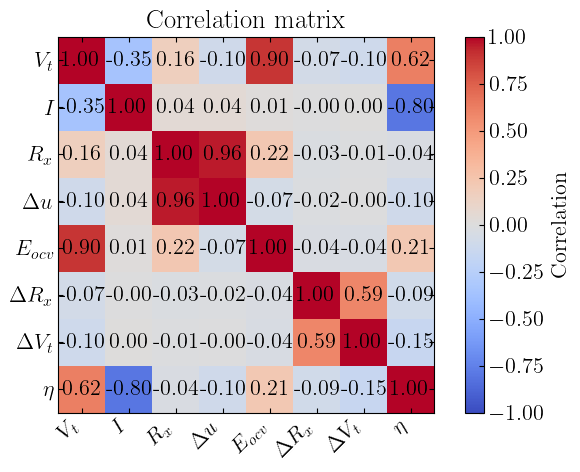

In [8]:
# Correlation matrix for current signals in this batch

X = data[['V_t','I','Rx','u_par','ocv','dRx','dV_t','eta']].values
feature_names = ['$V_t$','$I$','$R_x$',r'$\Delta u$','$E_{ocv}$',r'$\Delta R_x$',r'$\Delta V_t$',r'$\eta$']
with np.errstate(invalid="ignore", divide="ignore"):
    corr = np.corrcoef(X, rowvar=False)


fig, ax_corr = plt.subplots(figsize=(7, 5))
im = ax_corr.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax_corr.set_xticks(np.arange(len(feature_names)))
ax_corr.set_yticks(np.arange(len(feature_names)))
ax_corr.set_xticklabels(feature_names, rotation=45, ha="right")
ax_corr.set_yticklabels(feature_names)
ax_corr.set_title("Correlation matrix")

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax_corr.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", color="black")

fig.colorbar(im, ax=ax_corr, label="Correlation")
plt.tight_layout()
plt.show()

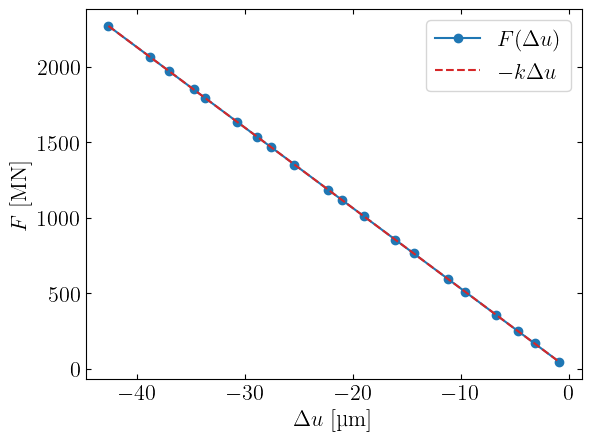

In [9]:
traj = 0
#plt.plot(data['u'][data['trajectory'] == traj], data['Rx'][data['trajectory'] == traj], lw = 2, color = colors[0])
groups = data.groupby('u')['Rx']


first_rx = data.groupby('u')['Rx'].first()
k = abs(first_rx / (data.groupby('u')['u'].first()))
plt.plot(data.groupby('u')['u'].first(), first_rx, 'o-', color = colors[0], label = r'$F(\Delta u)$')
plt.plot(data.groupby('u')['u'].first(), -k * data.groupby('u')['u'].first(), '--', color = colors[1], label = r'$-k\Delta u$')
plt.xlabel(r'$\Delta u$ [µm]')
plt.ylabel(r'$F$ [MN]')
plt.legend()

Text(0, 0.5, '$F$ [MN]')

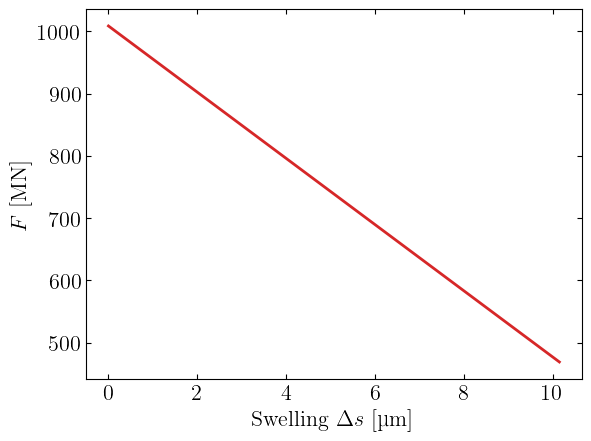

In [10]:
ds = -data['Rx'][data['trajectory'] == traj] / k.values[0] - data['u'][data['trajectory'] == traj] 

plt.plot(ds,data['Rx'][data['trajectory'] == traj], lw = 2, color = colors[1])
plt.xlabel(r'Swelling $\Delta s$ [µm]')
plt.ylabel(r'$F$ [MN]')

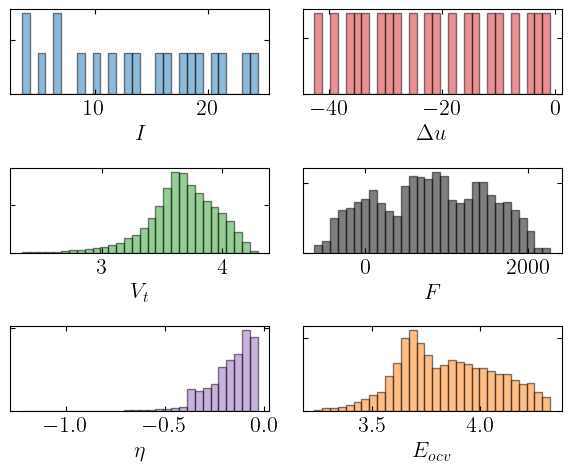

In [11]:
f, ax = plt.subplots(3,2,figsize=(6, 5))
ax[0,0].hist(np.unique(data['I']), bins=30, color=colors[0], alpha=0.5,edgecolor='black',density=True)
ax[0,1].hist(np.unique(data['u']) , bins=30, color=colors[1], alpha=0.5,edgecolor='black',density=True)
ax[1,0].hist(data['V_t'], bins=30, color=colors[2], alpha=0.5,edgecolor='black',density=True)
ax[1,1].hist(np.unique(data['Rx']), bins=30, color=colors[3], alpha=0.5,edgecolor='black',density=True)
ax[2,1].hist(data['ocv'], bins=30, color=colors[4], alpha=0.5,edgecolor='black',density=True)
ax[2,0].hist((data['eta']), bins=30, color=colors[5], alpha=0.5,edgecolor='black',density=True)
ax[0,0].set_xlabel('$I$')
ax[0,1].set_xlabel(r'$\Delta u$')
ax[1,0].set_xlabel('$V_t$')
ax[1,1].set_xlabel('$F$')
ax[2,1].set_xlabel('$E_{ocv}$')
ax[2,0].set_xlabel(r'$\eta$')
#ax[2,0].set_xlabel('$E_{ocv}$')
#ax[2,1].set_xlabel('$d$')
for a in ax.flat:
    a.set_yticklabels([])
plt.tight_layout()
plt.show()

# Normalizing data

### Characteristics that should be preserved after normalization?


- $\Delta u$: It should primarily be compression, so have a negative sign. 
    - $\Delta u / L$ gives a fractional compression 
- $I$: The sign of it should reflect if we have charge/discharge
    - Maybe just a `standard` normalization on this? 
- $V$: It should always be positive
    - Maybe just a `min-max` normalization on this? 
- $F$: The sign of it should in some way reflect the sign of $\Delta u$. Especially in the cases with low swelling. 
    - Maybe just a `standard` normalization on this? 

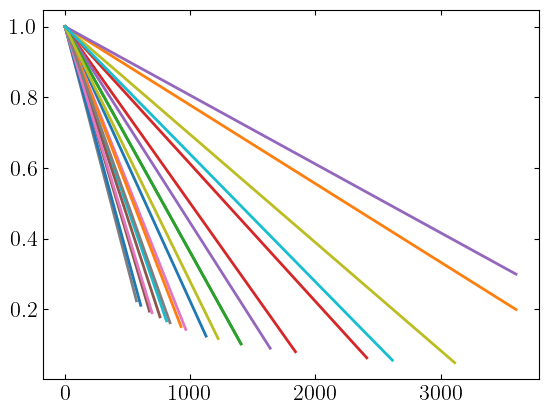

In [12]:

def SOC(Z_init, I, Q = Q0, dt = DT):
    return Z_init - I * dt / Q

for traj in data['trajectory'].unique():    
    soc = np.ones(len(data['I'][data['trajectory'] == traj]) + 1) * 1.0
    for i in 1 + np.arange(len(data['I'][data['trajectory'] == traj])):
        soc[i] = SOC(soc[i-1], data['I'][data['trajectory'] == traj].iloc[i-1])

    plt.plot(np.arange(len(soc))* DT,soc, lw = 2, label = f'I = {(data['I'][data['trajectory'] == traj].values)[0]} ')

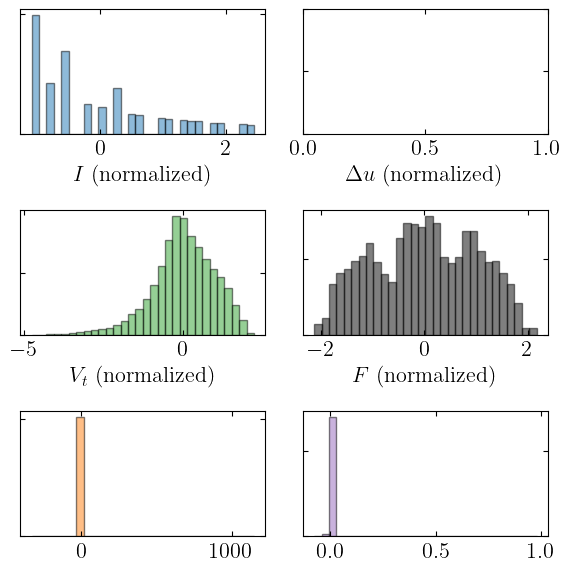

In [13]:
stats = {}

def compute_stats(x, name):
    if name == 'R':
        stats[name] = (np.min(x), np.max(x))
    else:
        stats[name] = (np.mean(x), np.std(x))
    return stats[name]
stats['I'] = compute_stats(data['I'], 'I')
stats['V_t'] = compute_stats(data['V_t'], 'V_t')
stats['u_par'] = compute_stats(data['u_par'], 'u_par')
stats['Rx'] = compute_stats(data['Rx'], 'Rx')





def normalize(x, name, stats = stats):
    #if name == 'R':
    return (x - stats[name][0]) / stats[name][1]
    #else: 
    #    return (x - stats[name][0]) / (stats[name][1] - stats[name][0])

    
def denormalize(x, name, stats=stats):
    #if name == 'R':
    return x * stats[name][1] + stats[name][0]
    #else:   
    #    return x * (stats[name][1] - stats[name][0]) + stats[name][0]
    
data['I_norm'] = normalize(data['I'], 'I')
data['V_t_norm'] = normalize(data['V_t'], 'V_t')
data['u_par_norm'] = normalize(data['u_par'], 'u_par')
data['Rx_norm'] = normalize(data['Rx'], 'Rx')

f, ax = plt.subplots(3,2,figsize=(6, 6))
ax[0,0].hist(data['I_norm'], bins=30, color=colors[0], alpha=0.5,edgecolor='black',density=True)
ax[1,0].hist(data['V_t_norm'], bins=30, color=colors[2], alpha=0.5,edgecolor='black',density=True)
ax[1,1].hist(data['Rx_norm'], bins=30, color=colors[3], alpha=0.5,edgecolor='black',density=True)
ax[2,0].hist(data['dRx'], bins=30, color=colors[4], alpha=0.5,edgecolor='black',density=True)
ax[2,1].hist(data['dV_t'], bins=30, color=colors[5], alpha=0.5,edgecolor='black',density=True)
ax[0,0].set_xlabel('$I$ (normalized)')
ax[0,1].set_xlabel(r'$\Delta u$ (normalized)')
ax[1,0].set_xlabel('$V_t$ (normalized)')
ax[1,1].set_xlabel('$F$ (normalized)')
for a in ax.flat:
    a.set_yticklabels([])
plt.tight_layout()
plt.show()